# FISTA-Net Replication — Mayo Clinic CT
**Paper:** *FISTA-Net: Learning A Fast Iterative Shrinkage Thresholding Network for Inverse Problems in Imaging*  
Xiang et al., IEEE Transactions on Medical Imaging, 2020

---
## Notebook Structure
1. Imports & device
2. CT data: download zip from Box (once) + extract
3. `MayoCTDataset` — reads local `.IMA` files, no streaming
4. EMT placeholder dataset (synthetic)
5. FISTA-Net model
6. Baseline models
7. Loss function & training loops
8. Smoke test
9. EMT experiment
10. CT experiment
11. Evaluation, tables & figures

## 1. Imports & Device

In [ ]:
# Install dependencies (run once)
!pip install torch torchvision numpy matplotlib scikit-image scipy tqdm pydicom requests -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 45.8 MB/s eta 0:00:00


In [ ]:
import os, io, json, math, zipfile, requests
from pathlib import Path
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import pydicom
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from skimage.transform import radon, iradon

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')


Using device: cuda


## 2. Download & Extract CT Data

Downloads `full_3mm.zip` from Box **once** and extracts it locally.  
After this cell you never need Box again — all data is read from disk.

> **Token expiry:** Box Developer Tokens last 60 min.  
> If you get a 401 error, regenerate at https://app.box.com/developers/console and update `BOX_DEV_TOKEN`.

In [ ]:
# ── Box credentials ──────────────────────────────────────────────────────────
BOX_DEV_TOKEN    = 'diUZsvYwUJXmZOfJUktASQWb0uT5u1qd'   # regenerate every 60 min if needed
SHARED_LINK      = 'https://aapm.app.box.com/s/eaw4jddb53keg1bptavvvd1sf4x3pe9h'
FULL_3MM_FILE_ID = '856956352254'   # full_3mm.zip in Training_Image_Data/3mm B30

CACHE_DIR   = './ct_cache'
ZIP_PATH    = os.path.join(CACHE_DIR, 'full_3mm.zip')
EXTRACT_DIR = os.path.join(CACHE_DIR, 'full_3mm', 'full_3mm')  # path after unzip
os.makedirs(CACHE_DIR, exist_ok=True)

# ── Download (skipped if already present) ────────────────────────────────────
if not os.path.exists(ZIP_PATH):
    print('Downloading full_3mm.zip ...')
    headers = {'Authorization': f'Bearer {BOX_DEV_TOKEN}',
               'BoxApi': f'shared_link={SHARED_LINK}'}
    resp = requests.get(
        f'https://api.box.com/2.0/files/{FULL_3MM_FILE_ID}/content',
        headers=headers, stream=True)
    resp.raise_for_status()
    total = int(resp.headers.get('content-length', 0))
    done  = 0
    with open(ZIP_PATH, 'wb') as f:
        for chunk in resp.iter_content(chunk_size=8*1024*1024):
            f.write(chunk); done += len(chunk)
            if total: print(f'  {done/1e6:.0f}/{total/1e6:.0f} MB', end='\r')
    print(f'\nDownloaded → {ZIP_PATH}')
else:
    print(f'Zip already present: {ZIP_PATH}')

# ── Extract (skipped if already done) ────────────────────────────────────────
extract_root = os.path.join(CACHE_DIR, 'full_3mm')
if not os.path.exists(extract_root):
    print('Extracting...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(extract_root)
    print(f'Extracted → {extract_root}')
else:
    print(f'Already extracted: {extract_root}')

# ── Verify structure ─────────────────────────────────────────────────────────
ima_files = list(Path(EXTRACT_DIR).rglob('*.IMA'))
print(f'\nTotal .IMA files found: {len(ima_files)}')
patients_found = sorted(set(p.parent.parent.name for p in ima_files))
print(f'Patients found: {patients_found}')



Downloaded → ./ct_cache/full_3mm.zip
Extracting...
Extracted → ./ct_cache/full_3mm

Total .IMA files found: 2378
Patients found: ['L067', 'L096', 'L109', 'L143', 'L192', 'L286', 'L291', 'L310', 'L333', 'L506']


## 3. MayoCTDataset — Local File Loader

Reads `.IMA` DICOM files directly from disk.  
No Box streaming, no indexing — just `Path.glob`.

**Folder layout inside the zip:**
```
ct_cache/full_3mm/full_3mm/
  L067/full_3mm/*.IMA   ← full-dose slices (ground truth)
  L096/full_3mm/*.IMA
  ...
```

Training:
  L067: 30/224 slices
  L096: 30/330 slices
  L109: 30/128 slices
  L143: 30/234 slices
  L192: 30/240 slices
  L286: 30/210 slices
  L291: 30/343 slices
  L310: 30/214 slices

Dataset ready: 240 total slices [60-view]

Validation:
  L333: 10/244 slices

Dataset ready: 10 total slices [60-view]

Test:
  L506: 10/211 slices

Dataset ready: 10 total slices [60-view]


/usr/local/lib/python3.12/dist-packages/skimage/transform/radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(
/usr/local/lib/python3.12/dist-packages/skimage/transform/radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(



FBP  : torch.Size([2, 1, 128, 128])
Sino : torch.Size([2, 1, 128, 60])
GT   : torch.Size([2, 1, 128, 128])  range: [0.000, 1.000]


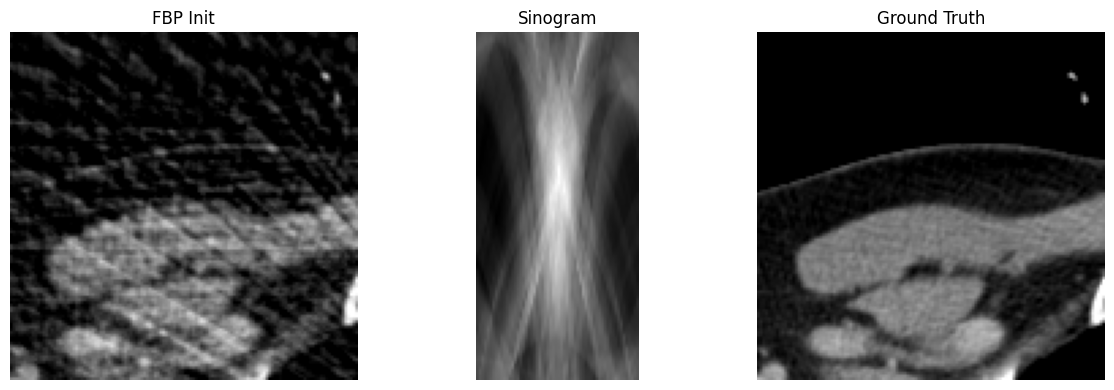

CT data loaded successfully ✓


In [ ]:
# ── Config ───────────────────────────────────────────────────────────────────
N_VIEWS                  = 60
BATCH_SIZE_CT            = 2
IMAGE_SIZE_CT            = 512
PATCH_SIZE               = 128   # train on 128×128 crops to fit 14GB VRAM
SLICES_PER_PATIENT_TRAIN = 30    # 30 × 8 patients = 240 train slices
SLICES_PER_PATIENT_VAL   = 10    # 10 × 1 = 10 val slices
SLICES_PER_PATIENT_TEST  = 10    # 10 × 1 = 10 test slices

TRAIN_PATIENTS = ['L067', 'L096', 'L109', 'L143', 'L192', 'L286', 'L291', 'L310']
VAL_PATIENTS   = ['L333']
TEST_PATIENTS  = ['L506']

WIN_MIN, WIN_MAX = -140, 260


def load_ima_file(path):
    ds        = pydicom.dcmread(str(path))
    img       = ds.pixel_array.astype(np.float32)
    slope     = float(getattr(ds, 'RescaleSlope',     1.0))
    intercept = float(getattr(ds, 'RescaleIntercept', 0.0))
    return np.clip((img * slope + intercept - WIN_MIN) / (WIN_MAX - WIN_MIN),
                   0., 1.).astype(np.float32)


def make_sparse_sinogram(img, n_views):
    angles   = np.linspace(0., 180., n_views, endpoint=False)
    sinogram = radon(img, theta=angles, circle=True).astype(np.float32)
    fbp_init = np.clip(
        iradon(sinogram, theta=angles, filter_name='ramp', circle=True), 0., 1.
    ).astype(np.float32)
    return sinogram, fbp_init


class MayoCTDataset(Dataset):
    def __init__(self, extract_dir, patients, n_views=60,
                 slices_per_patient=None, patch_size=None):
        self.n_views    = n_views
        self.patch_size = patch_size
        self.samples    = []

        for pid in patients:
            patient_dir = Path(extract_dir) / pid / 'full_3mm'
            if not patient_dir.exists():
                print(f'WARNING: {patient_dir} not found, skipping')
                continue
            all_slices = sorted(patient_dir.glob('*.IMA'))
            # Take a fixed subset if requested, otherwise use all
            slices = all_slices[:slices_per_patient] if slices_per_patient else all_slices
            if len(slices) == 0:
                print(f'WARNING: no .IMA files in {patient_dir}')
                continue
            self.samples.extend(slices)
            print(f'  {pid}: {len(slices)}/{len(all_slices)} slices')

        print(f'\nDataset ready: {len(self.samples)} total slices [{n_views}-view]')
        assert len(self.samples) > 0, f'No slices found in {extract_dir}'

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        gt        = load_ima_file(self.samples[idx])
        sino, fbp = make_sparse_sinogram(gt, self.n_views)
        if self.patch_size:
            p = self.patch_size; H, W = gt.shape
            r = np.random.randint(0, H - p); c = np.random.randint(0, W - p)
            gt  = gt[ r:r+p, c:c+p]
            fbp = fbp[r:r+p, c:c+p]
            sino = sino[r:r+p, :]
        return (torch.tensor(fbp,  dtype=torch.float32).unsqueeze(0),
                torch.tensor(sino, dtype=torch.float32).unsqueeze(0),
                torch.tensor(gt,   dtype=torch.float32).unsqueeze(0))


# ── Build datasets ────────────────────────────────────────────────────────────
print('Training:')
train_dataset_ct = MayoCTDataset(EXTRACT_DIR, TRAIN_PATIENTS, N_VIEWS,
                                  slices_per_patient=SLICES_PER_PATIENT_TRAIN,
                                  patch_size=PATCH_SIZE)
print('\nValidation:')
val_dataset_ct   = MayoCTDataset(EXTRACT_DIR, VAL_PATIENTS, N_VIEWS,
                                  slices_per_patient=SLICES_PER_PATIENT_VAL,
                                  patch_size=PATCH_SIZE)
print('\nTest:')
test_dataset_ct  = MayoCTDataset(EXTRACT_DIR, TEST_PATIENTS, N_VIEWS,
                                  slices_per_patient=SLICES_PER_PATIENT_TEST,
                                  patch_size=PATCH_SIZE)

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader_ct = DataLoader(train_dataset_ct, batch_size=BATCH_SIZE_CT,
                              shuffle=True,  num_workers=2, pin_memory=True)
val_loader_ct   = DataLoader(val_dataset_ct,   batch_size=BATCH_SIZE_CT,
                              shuffle=False, num_workers=2)
test_loader_ct  = DataLoader(test_dataset_ct,  batch_size=BATCH_SIZE_CT,
                              shuffle=False, num_workers=2)

# ── Sanity check ─────────────────────────────────────────────────────────────
fbp_b, sino_b, gt_b = next(iter(train_loader_ct))
print(f'\nFBP  : {fbp_b.shape}')
print(f'Sino : {sino_b.shape}')
print(f'GT   : {gt_b.shape}  range: [{gt_b.min():.3f}, {gt_b.max():.3f}]')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title in zip(axes,
                           [fbp_b[0,0], sino_b[0,0], gt_b[0,0]],
                           ['FBP Init', 'Sinogram', 'Ground Truth']):
    ax.imshow(img.numpy(), cmap='gray'); ax.set_title(title); ax.axis('off')
plt.tight_layout()
plt.savefig('sample_ct_slice.png', dpi=150, bbox_inches='tight')
plt.show()
print('CT data loaded successfully ✓')

---
> ## ⚠️  EMT SECTION — Electrical Impedance Tomography
> The cells below are **EMT-specific** and are intentionally kept separate from the
> CT pipeline.  They can be run independently once EMT data is available.
> **Skip to the next CT section to continue with the CT experiments.**
---


## 4. EMT Placeholder Dataset (synthetic)
Generates synthetic (measurement, image) pairs matching the paper spec.  
Replace `_generate_sample()` with real COMSOL data when available.

In [ ]:
class EMTDataset(Dataset):
    MEASUREMENT_DIM = 64
    IMAGE_SIZE      = 64
    CONDUCTIVITY_LO = 0.05
    CONDUCTIVITY_HI = 0.50
    TRAIN_SNR_DB    = 40

    def __init__(self, split='train', size=None):
        self.split = split
        default_sizes = {'train': 19200, 'val': 4800, 'test1': 6000, 'test2': 6000}
        self.size = size if size is not None else default_sizes[split]
        self.n_objects_range = (3, 3) if split == 'test2' else (1, 4)

    def _generate_sample(self):
        img = np.zeros((self.IMAGE_SIZE, self.IMAGE_SIZE), dtype=np.float32)
        n   = np.random.randint(*self.n_objects_range) + 1
        r_max = self.IMAGE_SIZE // 6
        for _ in range(n):
            cx   = np.random.randint(r_max, self.IMAGE_SIZE - r_max)
            cy   = np.random.randint(r_max, self.IMAGE_SIZE - r_max)
            r    = np.random.randint(4, r_max)
            cond = np.random.uniform(self.CONDUCTIVITY_LO, self.CONDUCTIVITY_HI)
            Y, X = np.ogrid[:self.IMAGE_SIZE, :self.IMAGE_SIZE]
            img[(X-cx)**2 + (Y-cy)**2 <= r**2] = cond
        A    = np.random.randn(self.MEASUREMENT_DIM, self.IMAGE_SIZE**2).astype(np.float32)
        A   /= np.linalg.norm(A, axis=1, keepdims=True) + 1e-8
        meas = A @ img.flatten()
        if self.split in ('train', 'val'):
            snr  = 10 ** (self.TRAIN_SNR_DB / 10)
            meas = meas + np.random.randn(*meas.shape).astype(np.float32) * np.sqrt(
                (np.mean(meas**2) + 1e-12) / snr)
        return meas, img

    def __len__(self): return self.size

    def __getitem__(self, idx):
        m, img = self._generate_sample()
        return (torch.tensor(m,   dtype=torch.float32),
                torch.tensor(img, dtype=torch.float32).unsqueeze(0))


m, img = EMTDataset('train', size=2)[0]
print(f'EMT — measurement: {m.shape}, image: {img.shape}, range: [{img.min():.3f}, {img.max():.3f}]')


EMT — measurement: torch.Size([64]), image: torch.Size([1, 64, 64]), range: [0.000, 0.401]


---
> ## ✅  END OF EMT SECTION
> The CT-specific code resumes after this point.
---


## 5. FISTA-Net Model (Section III)

In [ ]:
class ProximalMappingNetwork(nn.Module):
    """
    4-layer CNN proximal operator with skip connection.
    Encoder F: [Conv+ReLU]×4   Decoder F̃: [Conv+ReLU]×3 + Conv   (no BatchNorm)
    Weights shared across stages; only threshold θ varies per stage.
    """
    def __init__(self, n_filters=32):
        super().__init__()
        Nf = n_filters
        self.encoder = nn.Sequential(
            nn.Conv2d(1,  Nf, 3, padding=1, bias=False), nn.ReLU(inplace=True),
            nn.Conv2d(Nf, Nf, 3, padding=1, bias=False), nn.ReLU(inplace=True),
            nn.Conv2d(Nf, Nf, 3, padding=1, bias=False), nn.ReLU(inplace=True),
            nn.Conv2d(Nf, Nf, 3, padding=1, bias=False), nn.ReLU(inplace=True),
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(Nf, Nf, 3, padding=1, bias=False), nn.ReLU(inplace=True),
            nn.Conv2d(Nf, Nf, 3, padding=1, bias=False), nn.ReLU(inplace=True),
            nn.Conv2d(Nf, Nf, 3, padding=1, bias=False), nn.ReLU(inplace=True),
            nn.Conv2d(Nf, 1,  3, padding=1, bias=False),
        )

    def encode(self, x): return self.encoder(x)
    def decode(self, z): return self.decoder(z)

    def forward(self, r, theta):
        z        = self.encode(r)
        z_thresh = F.relu(z - theta) - F.relu(-z - theta)   # soft-threshold
        return self.decode(z_thresh) + r, z                  # skip + return z for loss


class FISTANet(nn.Module):
    """
    Unrolled FISTA with learned μ, θ, ρ (Section III).
    For CT the A matrix is a dummy 1×1 eye — actual A/A^T go through RadonOperator.
    """
    def __init__(self, A_matrix, n_stages=7, n_filters=32, image_size=64):
        super().__init__()
        self.Ns = n_stages; self.img_size = image_size
        self.register_buffer('A', A_matrix.float())
        self.register_buffer('W_tilde', self._compute_W_tilde(A_matrix))
        self.prox_net = ProximalMappingNetwork(n_filters)
        # Learnable scalars — init from paper Section III-C
        self.w1 = nn.Parameter(torch.tensor(-0.5))
        self.c1 = nn.Parameter(torch.tensor(-2.0))
        self.w2 = nn.Parameter(torch.tensor(-0.2))
        self.c2 = nn.Parameter(torch.tensor(-1.0))
        self.w3 = nn.Parameter(torch.tensor( 1.0))
        self.c3 = nn.Parameter(torch.tensor( 0.0))

    @staticmethod
    def _compute_W_tilde(A):
        A = A.float()
        return (A / A.norm(dim=0, keepdim=True).clamp(min=1e-8)).T

    def _mu(self, k):
        return F.softplus(-F.softplus(-self.w1) * k + self.c1)

    def _theta(self, k):
        return F.softplus(-F.softplus(-self.w2) * k + self.c2)

    def _rho(self, k):
        w3  = F.softplus(self.w3)
        num = F.softplus(w3*k + self.c3) - F.softplus(w3 + self.c3)
        return (num / F.softplus(w3*k + self.c3).clamp(1e-8)).clamp(0, 1)

    def forward(self, b, x0):
        """EMT forward pass — uses explicit A matrix."""
        B, _, H, W = x0.shape; N = H * W
        x_prev = x0; y = x0; ints = []
        for k in range(1, self.Ns + 1):
            mu = self._mu(k); theta = self._theta(k); rho = self._rho(k)
            res  = (self.A @ y.view(B,N).T).T - b
            r    = y - mu * (self.W_tilde @ res.T).T.view(B,1,H,W)
            x, z = self.prox_net(r, theta)
            y    = x + rho*(x - x_prev); x_prev = x; ints.append((x, z))
        return x, ints

    def get_learned_params(self):
        mus, thetas, rhos = [], [], []
        with torch.no_grad():
            for k in range(1, self.Ns+1):
                mus.append(self._mu(k).item())
                thetas.append(self._theta(k).item())
                rhos.append(self._rho(k).item())
        return mus, thetas, rhos


print('FISTANet defined.')


FISTANet defined.


## 6. Baseline Models

In [ ]:
# ── Laplacian Regularization ─────────────────────────────────────────────────
def laplacian_regularization(b, A, image_size=64, lam=0.001):
    from scipy.sparse import diags
    n  = image_size
    D1 = diags([-1,2,-1],[-1,0,1],shape=(n,n)).toarray()
    I  = np.eye(n)
    L  = np.kron(D1,I) + np.kron(I,D1)
    return np.linalg.solve(A.T@A + lam*L.T@L, A.T@b).reshape(n,n)


# ── FISTA-TV ──────────────────────────────────────────────────────────────────
def tv_prox(x, lam_tv):
    dx  = np.diff(x, axis=1, append=x[:,-1:])
    dy  = np.diff(x, axis=0, append=x[-1:,:])
    mag = np.sqrt(dx**2 + dy**2 + 1e-8)
    dx /= mag; dy /= mag
    return x - lam_tv*(dx - np.roll(dx,1,axis=1) + dy - np.roll(dy,1,axis=0))

def fista_tv(b, A, x0, n_iters=100, lam=0.001, image_size=64):
    L = np.linalg.norm(A, ord=2)**2 + 1e-6; mu = 1./L
    x = x0.flatten(); y = x.copy(); t = 1.; xp = x.copy()
    for _ in range(n_iters):
        r    = y - mu*(A.T@(A@y - b))
        x    = tv_prox(r.reshape(image_size,image_size), lam*mu).flatten()
        t_new = (1 + math.sqrt(1+4*t**2))/2
        y    = x + ((t-1)/t_new)*(x - xp); xp, t = x.copy(), t_new
    return x.reshape(image_size, image_size)


# ── FBPConvNet (U-Net) ────────────────────────────────────────────────────────
class UNetBlock(nn.Module):
    def __init__(self, ic, oc):
        super().__init__()
        self.b = nn.Sequential(
            nn.Conv2d(ic,oc,3,padding=1), nn.BatchNorm2d(oc), nn.ReLU(inplace=True),
            nn.Conv2d(oc,oc,3,padding=1), nn.BatchNorm2d(oc), nn.ReLU(inplace=True))
    def forward(self,x): return self.b(x)

class FBPConvNet(nn.Module):
    def __init__(self, base_ch=32):
        super().__init__()
        b = base_ch; self.pool = nn.MaxPool2d(2)
        self.e1=UNetBlock(1,b);   self.e2=UNetBlock(b,b*2)
        self.e3=UNetBlock(b*2,b*4); self.e4=UNetBlock(b*4,b*8)
        self.bn=UNetBlock(b*8,b*16)
        self.u4=nn.ConvTranspose2d(b*16,b*8,2,stride=2); self.d4=UNetBlock(b*16,b*8)
        self.u3=nn.ConvTranspose2d(b*8, b*4,2,stride=2); self.d3=UNetBlock(b*8, b*4)
        self.u2=nn.ConvTranspose2d(b*4, b*2,2,stride=2); self.d2=UNetBlock(b*4, b*2)
        self.u1=nn.ConvTranspose2d(b*2, b,  2,stride=2); self.d1=UNetBlock(b*2, b)
        self.out=nn.Conv2d(b,1,1)
    def forward(self,x):
        e1=self.e1(x); e2=self.e2(self.pool(e1))
        e3=self.e3(self.pool(e2)); e4=self.e4(self.pool(e3))
        d =self.bn(self.pool(e4))
        d =self.d4(torch.cat([self.u4(d),e4],1))
        d =self.d3(torch.cat([self.u3(d),e3],1))
        d =self.d2(torch.cat([self.u2(d),e2],1))
        d =self.d1(torch.cat([self.u1(d),e1],1))
        return self.out(d) + x


# ── ISTA-Net ──────────────────────────────────────────────────────────────────
class ISTANet(nn.Module):
    def __init__(self, A_matrix, n_stages=6, n_filters=32, image_size=64):
        super().__init__()
        self.Ns=n_stages; self.img_size=image_size
        self.register_buffer('A', A_matrix.float())
        self.prox_net = ProximalMappingNetwork(n_filters)
        self.mus    = nn.ParameterList([nn.Parameter(torch.tensor(0.1)) for _ in range(n_stages)])
        self.thetas = nn.ParameterList([nn.Parameter(torch.tensor(0.1)) for _ in range(n_stages)])
    def forward(self, b, x0):
        B,_,H,W = x0.shape; N = H*W; x = x0; ints = []
        for k in range(self.Ns):
            r = x - self.mus[k]*((self.A.T@((self.A@x.view(B,N).T).T - b).T).T).view(B,1,H,W)
            x, z = self.prox_net(r, self.thetas[k]); ints.append((x,z))
        return x, ints


print(f'Baselines defined. FBPConvNet params: {sum(p.numel() for p in FBPConvNet().parameters()):,}')


Baselines defined. FBPConvNet params: 7,765,409


## 7. Loss Function & Training Loops

In [ ]:
def fista_net_loss(x_final, intermediates, x_gt, prox_net, lambda1=0.01, lambda2=0.001):
    """Eq. 14: L_total = L_mse + λ1*L_sym + λ2*L_spa"""
    L_mse = F.mse_loss(x_final, x_gt)
    L_sym = L_spa = torch.tensor(0., device=x_final.device)
    for x_k, z_k in intermediates:
        L_sym += F.mse_loss(prox_net.decode(prox_net.encode(x_k)), x_k)
        L_spa += z_k.abs().mean()
    L_sym /= len(intermediates); L_spa /= len(intermediates)
    return L_mse + lambda1*L_sym + lambda2*L_spa, L_mse, L_sym, L_spa


def compute_metrics(pred, gt):
    if pred.ndim == 2: pred, gt = pred[np.newaxis], gt[np.newaxis]
    ps, ss, rs = [], [], []
    for p, g in zip(pred, gt):
        dr = max(g.max()-g.min(), 1e-8)
        ps.append(psnr(g,p,data_range=dr))
        ss.append(ssim(g,p,data_range=dr))
        rs.append(np.sqrt(np.mean((p-g)**2)))
    return {'PSNR': np.mean(ps), 'SSIM': np.mean(ss), 'RMSE': np.mean(rs)}


# ── EMT training loop ─────────────────────────────────────────────────────────
def train_fista_net_emt(model, train_loader, val_loader,
                        n_epochs=100, lr_net=1e-4, lr_params=1e-3,
                        lambda1=0.01, lambda2=0.001, device=DEVICE):
    model = model.to(device)
    optimizer = torch.optim.Adam([
        {'params': list(model.prox_net.parameters()), 'lr': lr_net},
        {'params': [model.w1,model.c1,model.w2,model.c2,model.w3,model.c3], 'lr': lr_params},
    ])
    history = {'train_loss':[], 'val_loss':[], 'val_psnr':[]}
    best_psnr, best_state = -np.inf, None

    for epoch in range(1, n_epochs+1):
        model.train(); ep_loss = 0.
        for b, x_gt in tqdm(train_loader, desc=f'Epoch {epoch}/{n_epochs}', leave=False):
            b, x_gt = b.to(device), x_gt.to(device)
            x_final, ints = model(b, torch.zeros_like(x_gt))
            loss, *_ = fista_net_loss(x_final, ints, x_gt, model.prox_net, lambda1, lambda2)
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); ep_loss += loss.item()

        model.eval(); vl = vp = 0.
        with torch.no_grad():
            for b, x_gt in val_loader:
                b, x_gt = b.to(device), x_gt.to(device)
                x_final, ints = model(b, torch.zeros_like(x_gt))
                loss, *_ = fista_net_loss(x_final, ints, x_gt, model.prox_net, lambda1, lambda2)
                vl += loss.item()
                vp += compute_metrics(x_final.squeeze(1).cpu().numpy(),
                                      x_gt.squeeze(1).cpu().numpy())['PSNR']
        avg_vp = vp / len(val_loader)
        history['train_loss'].append(ep_loss/len(train_loader))
        history['val_loss'].append(vl/len(val_loader))
        history['val_psnr'].append(avg_vp)
        if avg_vp > best_psnr: best_psnr = avg_vp; best_state = deepcopy(model.state_dict())
        if epoch % 10 == 0:
            print(f'Epoch {epoch:3d} | Train: {history["train_loss"][-1]:.4f} | Val PSNR: {avg_vp:.2f} dB')

    model.load_state_dict(best_state)
    print(f'Done. Best Val PSNR: {best_psnr:.2f} dB')
    return model, history


# ── CT training loop (implicit Radon) ─────────────────────────────────────────
def train_fista_net_ct(fista_model, radon_op, train_loader, val_loader,
                       n_epochs=100, lr_net=1e-4, lr_params=1e-3,
                       lambda1=0.01, lambda2=0.001, device=DEVICE):
    """
    CT training loop. The Radon operator replaces the explicit A matrix:
      gradient step: r = y - μ * A^T(Ay - b)  via radon_op.batch_forward/adjoint
    """
    fista_model = fista_model.to(device)
    optimizer = torch.optim.Adam([
        {'params': list(fista_model.prox_net.parameters()), 'lr': lr_net},
        {'params': [fista_model.w1,fista_model.c1,fista_model.w2,
                    fista_model.c2,fista_model.w3,fista_model.c3], 'lr': lr_params},
    ])
    best_psnr, best_state = -float('inf'), None
    history = {'train_loss':[], 'val_psnr':[]}

    for epoch in range(1, n_epochs+1):
        fista_model.train(); ep_loss = 0.

        for fbp, sino, gt in tqdm(train_loader, desc=f'Epoch {epoch}/{n_epochs}', leave=False):
            fbp, sino, gt = fbp.to(device), sino.to(device), gt.to(device)
            x_prev = y = fbp; ints = []
            for k in range(1, fista_model.Ns+1):
                mu    = fista_model._mu(k)
                theta = fista_model._theta(k)
                rho   = fista_model._rho(k)
                Ay    = radon_op.batch_forward(y).to(device)
                r     = y - mu * radon_op.batch_adjoint(Ay - sino).to(device)
                x, z  = fista_model.prox_net(r, theta)
                y     = x + rho*(x - x_prev); x_prev = x; ints.append((x,z))

            loss, *_ = fista_net_loss(x, ints, gt, fista_model.prox_net, lambda1, lambda2)
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(fista_model.parameters(), 1.0)
            optimizer.step(); ep_loss += loss.item()

        fista_model.eval(); val_psnrs = []
        with torch.no_grad():
            for fbp, sino, gt in val_loader:
                fbp, sino, gt = fbp.to(device), sino.to(device), gt.to(device)
                x_prev = y = fbp
                for k in range(1, fista_model.Ns+1):
                    mu=fista_model._mu(k); theta=fista_model._theta(k); rho=fista_model._rho(k)
                    Ay = radon_op.batch_forward(y).to(device)
                    r  = y - mu * radon_op.batch_adjoint(Ay - sino).to(device)
                    x, _ = fista_model.prox_net(r, theta)
                    y = x + rho*(x - x_prev); x_prev = x
                for p, g in zip(x.squeeze(1).cpu().numpy(), gt.squeeze(1).cpu().numpy()):
                    val_psnrs.append(psnr(g, p, data_range=g.max()-g.min()+1e-8))

        avg_vp = np.mean(val_psnrs)
        history['train_loss'].append(ep_loss/len(train_loader))
        history['val_psnr'].append(avg_vp)
        if avg_vp > best_psnr: best_psnr = avg_vp; best_state = deepcopy(fista_model.state_dict())
        if epoch % 10 == 0:
            print(f'Epoch {epoch:3d} | Loss: {ep_loss/len(train_loader):.4f} | Val PSNR: {avg_vp:.2f} dB')

    fista_model.load_state_dict(best_state)
    print(f'Done. Best Val PSNR: {best_psnr:.2f} dB')
    return fista_model, history


print('Training loops defined.')


Training loops defined.


## 8. Smoke Test

In [ ]:
IMAGE_SIZE = 64; MEAS_DIM = 64; BATCH_SIZE = 4

A_np     = np.random.randn(MEAS_DIM, IMAGE_SIZE**2).astype(np.float32)
A_np    /= np.linalg.norm(A_np, axis=1, keepdims=True) + 1e-8
A_tensor = torch.tensor(A_np)

train_loader_emt = DataLoader(EMTDataset('train', size=32), batch_size=BATCH_SIZE, shuffle=True)
val_loader_emt   = DataLoader(EMTDataset('val',   size=16), batch_size=BATCH_SIZE, shuffle=False)

fista_net_emt = FISTANet(A_tensor, n_stages=7, n_filters=32, image_size=IMAGE_SIZE).to(DEVICE)
print(f'FISTA-Net params: {sum(p.numel() for p in fista_net_emt.parameters()):,}')

b_t, gt_t = next(iter(train_loader_emt))
with torch.no_grad():
    x_out, _ = fista_net_emt(b_t.to(DEVICE), torch.zeros_like(gt_t).to(DEVICE))
print(f'Output: {x_out.shape}  expected: {gt_t.shape}')
print('Smoke test PASSED ✓')


FISTA-Net params: 55,878
Output: torch.Size([4, 1, 64, 64])  expected: torch.Size([4, 1, 64, 64])
Smoke test PASSED ✓


---
> ## ⚠️  EMT SECTION — Electrical Impedance Tomography
> The cells below are **EMT-specific** and are intentionally kept separate from the
> CT pipeline.  They can be run independently once EMT data is available.
> **Skip to the next CT section to continue with the CT experiments.**
---


## 9. EMT Experiment (Section IV-A)

In [ ]:
N_EPOCHS_EMT = 1   # paper default

fista_net_emt, history_emt = train_fista_net_emt(
    model=fista_net_emt, train_loader=train_loader_emt, val_loader=val_loader_emt,
    n_epochs=N_EPOCHS_EMT, lr_net=1e-4, lr_params=1e-3,
    lambda1=0.01, lambda2=0.001, device=DEVICE)
torch.save(fista_net_emt.state_dict(), 'fista_net_emt.pth')
print('Saved → fista_net_emt.pth')


Done. Best Val PSNR: 13.22 dB
Saved → fista_net_emt.pth


---
> ## ✅  END OF EMT SECTION
> The CT-specific code resumes after this point.
---


## 10. CT Experiment — Mayo Clinic Data (Section IV-B)

Uses `MayoCTDataset` (Section 3) and an implicit `RadonOperator` for the forward/adjoint steps.

In [ ]:
class RadonOperator:
    def __init__(self, image_size=128, n_views=60):
        self.angles     = np.linspace(0., 180., n_views, endpoint=False)
        self.image_size = image_size

    def batch_forward(self, x_batch):
        sinos = [radon(x_batch[i,0].detach().cpu().numpy(),
                       theta=self.angles, circle=True)
                 for i in range(x_batch.shape[0])]
        return torch.tensor(np.stack(sinos), dtype=torch.float32).unsqueeze(1)

    def batch_adjoint(self, sino_batch):
        imgs = [iradon(sino_batch[i,0].detach().cpu().numpy(),
                       theta=self.angles, filter_name='ramp', circle=True)
                for i in range(sino_batch.shape[0])]
        return torch.tensor(np.stack(imgs), dtype=torch.float32).unsqueeze(1)


# Use patch size for the operator too
eff_size = PATCH_SIZE if PATCH_SIZE else IMAGE_SIZE_CT
radon_op = RadonOperator(image_size=eff_size, n_views=N_VIEWS)

# Clear any leftover GPU memory before building model
torch.cuda.empty_cache()

dummy_A      = torch.eye(1)
fista_net_ct = FISTANet(dummy_A, n_stages=7, n_filters=32,
                         image_size=eff_size).to(DEVICE)
print(f'FISTA-Net CT params: {sum(p.numel() for p in fista_net_ct.parameters()):,}')
print(f'Training on {eff_size}×{eff_size} patches')

FISTA-Net CT params: 55,878
Training on 128×128 patches


In [ ]:
import os
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'
torch.cuda.empty_cache()

N_EPOCHS_CT = 10

fista_net_ct, history_ct = train_fista_net_ct(
    fista_model  = fista_net_ct,
    radon_op     = radon_op,
    train_loader = train_loader_ct,
    val_loader   = val_loader_ct,
    n_epochs     = N_EPOCHS_CT,
    lr_net       = 1e-4,
    lr_params    = 1e-3,
    lambda1      = 0.01,
    lambda2      = 0.001,
    device       = DEVICE,
)
torch.save(fista_net_ct.state_dict(), 'fista_net_ct_mayo.pth')
print('Saved → fista_net_ct_mayo.pth')

Epoch  10 | Loss: 0.0036 | Val PSNR: 24.28 dB
Done. Best Val PSNR: 25.52 dB
Saved → fista_net_ct_mayo.pth


## 11. Evaluation, Tables & Figures

---
> ## ⚠️  EMT SECTION — Electrical Impedance Tomography
> The cells below are **EMT-specific** and are intentionally kept separate from the
> CT pipeline.  They can be run independently once EMT data is available.
> **Skip to the next CT section to continue with the CT experiments.**
---


In [ ]:
# ── Table II: EMT results ─────────────────────────────────────────────────────
def evaluate_all_emt(fista_model, fbp_model, ista_model,
                     test_loader, A_np, image_size=64, device=DEVICE):
    methods = ['Lap.Reg','FISTA-TV','FBPConvNet','ISTA-Net','FISTA-Net']
    results = {m: {'PSNR':[],'SSIM':[],'RMSE':[]} for m in methods}
    for m in [fista_model, ista_model, fbp_model]: m.eval()
    with torch.no_grad():
        for b_batch, gt_batch in tqdm(test_loader, desc='Evaluating'):
            gt_np = gt_batch.squeeze(1).numpy()
            for i in range(b_batch.shape[0]):
                b_np = b_batch[i].numpy(); gt_i = gt_np[i]
                x_lap = laplacian_regularization(b_np, A_np, image_size)
                x_tv  = fista_tv(b_np, A_np, x_lap, image_size=image_size)
                for k in ('PSNR','SSIM','RMSE'):
                    results['Lap.Reg'][k].append(compute_metrics(x_lap, gt_i)[k])
                    results['FISTA-TV'][k].append(compute_metrics(x_tv,  gt_i)[k])
            b_t  = b_batch.to(device)
            x0_t = torch.zeros_like(gt_batch).to(device)
            fbp_out  = fbp_model(x0_t).squeeze(1).cpu().numpy()
            ista_out,_  = ista_model(b_t, x0_t); ista_out  = ista_out.squeeze(1).cpu().numpy()
            fista_out,_ = fista_model(b_t, x0_t); fista_out = fista_out.squeeze(1).cpu().numpy()
            for name, pred in [('FBPConvNet',fbp_out),('ISTA-Net',ista_out),('FISTA-Net',fista_out)]:
                m = compute_metrics(pred, gt_np)
                for k in ('PSNR','SSIM','RMSE'): results[name][k].append(m[k])
    return {method: {k: np.mean(v) for k,v in mets.items()} for method,mets in results.items()}


def print_table(results, title):
    print(f'\n{"─"*62}\n  {title}\n{"─"*62}')
    print(f'  {"Method":<15} {"PSNR":>8} {"SSIM":>8} {"RMSE":>8}')
    print(f'{"─"*62}')
    for method, m in results.items():
        print(f'  {method:<15} {m["PSNR"]:>8.3f} {m["SSIM"]:>8.3f} {m["RMSE"]:>8.3f}')
    print(f'{"─"*62}')


fbpconvnet_emt = FBPConvNet().to(DEVICE)
ista_net_emt   = ISTANet(A_tensor, n_stages=6, image_size=IMAGE_SIZE).to(DEVICE)

test_loader1 = DataLoader(EMTDataset('test1', size=32), batch_size=8, shuffle=False)
test_loader2 = DataLoader(EMTDataset('test2', size=32), batch_size=8, shuffle=False)

r1 = evaluate_all_emt(fista_net_emt, fbpconvnet_emt, ista_net_emt, test_loader1, A_np, IMAGE_SIZE)
r2 = evaluate_all_emt(fista_net_emt, fbpconvnet_emt, ista_net_emt, test_loader2, A_np, IMAGE_SIZE)
print_table(r1, 'Table II — EMT Test Set 1 (in-distribution)')
print_table(r2, 'Table II — EMT Test Set 2 (3-object OOD)')


Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]


ValueError: low >= high

In [ ]:
# ── Fig 6: Learned parameters ─────────────────────────────────────────────────
mus, thetas, rhos = fista_net_emt.get_learned_params()
stages = list(range(1, len(mus)+1))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
ax1.plot(stages, mus, 'b-o', label='μ (step size)')
ax1.plot(stages, thetas, 'r-s', label='θ (threshold)')
ax1.set_xlabel('Stage k'); ax1.set_title('Learned μ and θ'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(stages, rhos, 'g-^', label='ρ (momentum)')
ax2.set_xlabel('Stage k'); ax2.set_title('Learned ρ'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('fig_learned_params.png', dpi=150, bbox_inches='tight'); plt.show()


In [ ]:
# ── Fig 5/8: Intermediate reconstructions ─────────────────────────────────────
def plot_intermediates(model, b, x_gt, x0, title, device=DEVICE):
    model.eval()
    b, x0 = b[:1].to(device), x0[:1].to(device)
    B,_,H,W = x0.shape; N = H*W
    xp = x0; y = x0; imgs = [x0.squeeze().cpu().detach().numpy()]
    with torch.no_grad():
        for k in range(1, model.Ns+1):
            res = (model.A @ y.view(B,N).T).T - b
            r   = y - model._mu(k)*(model.W_tilde @ res.T).T.view(B,1,H,W)
            x,_ = model.prox_net(r, model._theta(k))
            y   = x + model._rho(k)*(x - xp); xp = x
            imgs.append(x.squeeze().cpu().numpy())
    all_imgs = imgs + [x_gt[:1].squeeze().numpy()]
    labels   = ['x₀'] + [f'Stage {k}' for k in range(1, model.Ns+1)] + ['GT']
    vmin = min(i.min() for i in all_imgs); vmax = max(i.max() for i in all_imgs)
    fig, axes = plt.subplots(1, len(all_imgs), figsize=(2.2*len(all_imgs), 3))
    for ax, img, lbl in zip(axes, all_imgs, labels):
        im = ax.imshow(img, cmap='hot', vmin=vmin, vmax=vmax)
        ax.set_title(lbl, fontsize=8); ax.axis('off')
    plt.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04)
    plt.suptitle(title, y=1.02); plt.tight_layout()
    plt.savefig(title.replace(' ','_').lower()+'.png', dpi=150, bbox_inches='tight'); plt.show()


b_demo, gt_demo = next(iter(test_loader1))
plot_intermediates(fista_net_emt, b_demo, gt_demo, torch.zeros_like(gt_demo),
                   'FISTA-Net EMT Iteration Results')


In [ ]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12,4))
epochs = range(1, len(history_emt['train_loss'])+1)
axes[0].plot(epochs, history_emt['train_loss'], label='Train')
axes[0].plot(epochs, history_emt['val_loss'],   label='Val')
axes[0].set_title('EMT Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs, history_emt['val_psnr'], 'g-o')
axes[1].set_title('EMT Val PSNR'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('fig_training_curves.png', dpi=150, bbox_inches='tight'); plt.show()
print('All figures saved.')


---
> ## ✅  END OF EMT SECTION
> The CT-specific code resumes after this point.
---



# CT Eval

In [ ]:
# ── CT Evaluation: PSNR, SSIM, RMSE on test set ──────────────────────────────
fista_net_ct.eval()
torch.cuda.empty_cache()

test_psnrs, test_ssims, test_rmses = [], [], []

with torch.no_grad():
    for fbp, sino, gt in tqdm(test_loader_ct, desc='Evaluating'):
        fbp, sino, gt = fbp.to(DEVICE), sino.to(DEVICE), gt.to(DEVICE)
        x_prev = y = fbp

        for k in range(1, fista_net_ct.Ns + 1):
            mu    = fista_net_ct._mu(k)
            theta = fista_net_ct._theta(k)
            rho   = fista_net_ct._rho(k)
            Ay    = radon_op.batch_forward(y).to(DEVICE)
            r     = y - mu * radon_op.batch_adjoint(Ay - sino).to(DEVICE)
            x, _  = fista_net_ct.prox_net(r, theta)
            y     = x + rho * (x - x_prev); x_prev = x

        pred_np = x.squeeze(1).cpu().numpy()
        gt_np   = gt.squeeze(1).cpu().numpy()
        fbp_np  = fbp.squeeze(1).cpu().numpy()

        for p, g in zip(pred_np, gt_np):
            dr = max(g.max() - g.min(), 1e-8)
            test_psnrs.append(psnr(g, p, data_range=dr))
            test_ssims.append(ssim(g, p, data_range=dr))
            test_rmses.append(np.sqrt(np.mean((p - g)**2)))

print('\n' + '─'*45)
print('  CT Test Set Results (Table V equivalent)')
print('─'*45)
print(f'  PSNR : {np.mean(test_psnrs):.3f} ± {np.std(test_psnrs):.3f} dB')
print(f'  SSIM : {np.mean(test_ssims):.3f} ± {np.std(test_ssims):.3f}')
print(f'  RMSE : {np.mean(test_rmses):.4f} ± {np.std(test_rmses):.4f}')
print('─'*45)

Evaluating: 100%|██████████| 5/5 [00:09<00:00,  1.87s/it]


─────────────────────────────────────────────
  CT Test Set Results (Table V equivalent)
─────────────────────────────────────────────
  PSNR : 25.793 ± 2.237 dB
  SSIM : 0.703 ± 0.047
  RMSE : 0.0529 ± 0.0133
─────────────────────────────────────────────


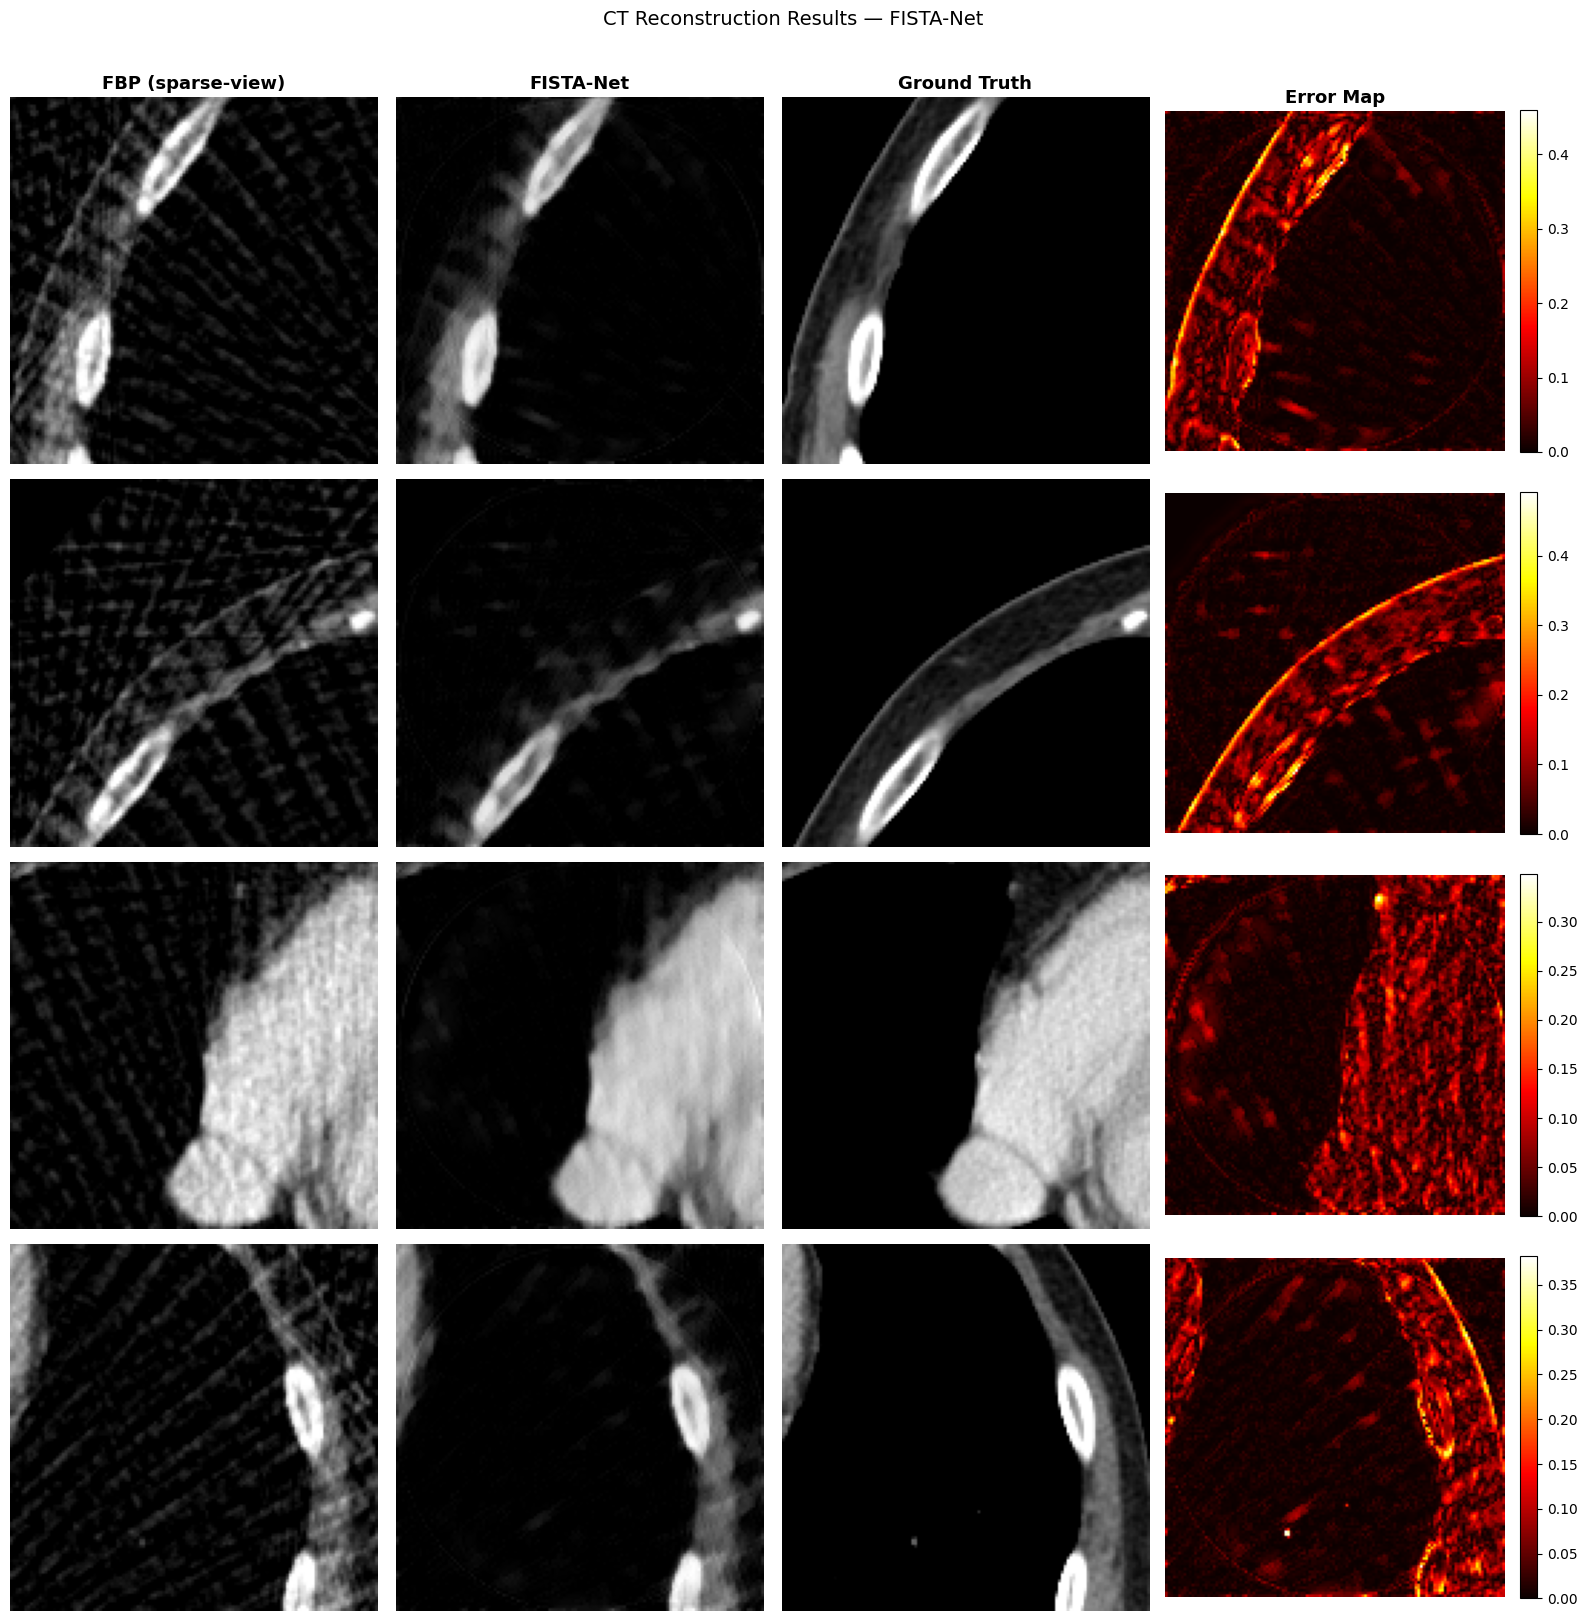

Saved → ct_reconstruction_results.png


In [ ]:
# ── Visual comparison: FBP vs FISTA-Net vs Ground Truth ──────────────────────
# Grab a few test samples for display
n_display = 4
display_samples = []

with torch.no_grad():
    for fbp, sino, gt in test_loader_ct:
        fbp, sino, gt = fbp.to(DEVICE), sino.to(DEVICE), gt.to(DEVICE)
        x_prev = y = fbp

        for k in range(1, fista_net_ct.Ns + 1):
            mu    = fista_net_ct._mu(k)
            theta = fista_net_ct._theta(k)
            rho   = fista_net_ct._rho(k)
            Ay    = radon_op.batch_forward(y).to(DEVICE)
            r     = y - mu * radon_op.batch_adjoint(Ay - sino).to(DEVICE)
            x, _  = fista_net_ct.prox_net(r, theta)
            y     = x + rho * (x - x_prev); x_prev = x

        for i in range(fbp.shape[0]):
            display_samples.append({
                'fbp':   fbp[i, 0].cpu().numpy(),
                'pred':  x[i, 0].cpu().numpy(),
                'gt':    gt[i, 0].cpu().numpy(),
            })
        if len(display_samples) >= n_display:
            break

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(n_display, 4, figsize=(16, 4 * n_display))
col_titles = ['FBP (sparse-view)', 'FISTA-Net', 'Ground Truth', 'Error Map']

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=13, fontweight='bold')

for row, sample in enumerate(display_samples[:n_display]):
    fbp_img  = sample['fbp']
    pred_img = sample['pred']
    gt_img   = sample['gt']
    err_img  = np.abs(pred_img - gt_img)

    # Use GT window for consistent display
    vmin, vmax = gt_img.min(), gt_img.max()

    # Metrics for this sample
    dr = max(gt_img.max() - gt_img.min(), 1e-8)
    p  = psnr(gt_img, pred_img, data_range=dr)
    s  = ssim(gt_img, pred_img, data_range=dr)
    r  = np.sqrt(np.mean((pred_img - gt_img)**2))

    axes[row, 0].imshow(fbp_img,  cmap='gray', vmin=vmin, vmax=vmax)
    axes[row, 1].imshow(pred_img, cmap='gray', vmin=vmin, vmax=vmax)
    axes[row, 2].imshow(gt_img,   cmap='gray', vmin=vmin, vmax=vmax)
    im = axes[row, 3].imshow(err_img, cmap='hot', vmin=0, vmax=err_img.max())
    plt.colorbar(im, ax=axes[row, 3], fraction=0.046, pad=0.04)

    axes[row, 1].set_ylabel(f'PSNR:{p:.2f} SSIM:{s:.3f} RMSE:{r:.4f}',
                             fontsize=9)

    for ax in axes[row]: ax.axis('off')

plt.suptitle('CT Reconstruction Results — FISTA-Net', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('ct_reconstruction_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ct_reconstruction_results.png')

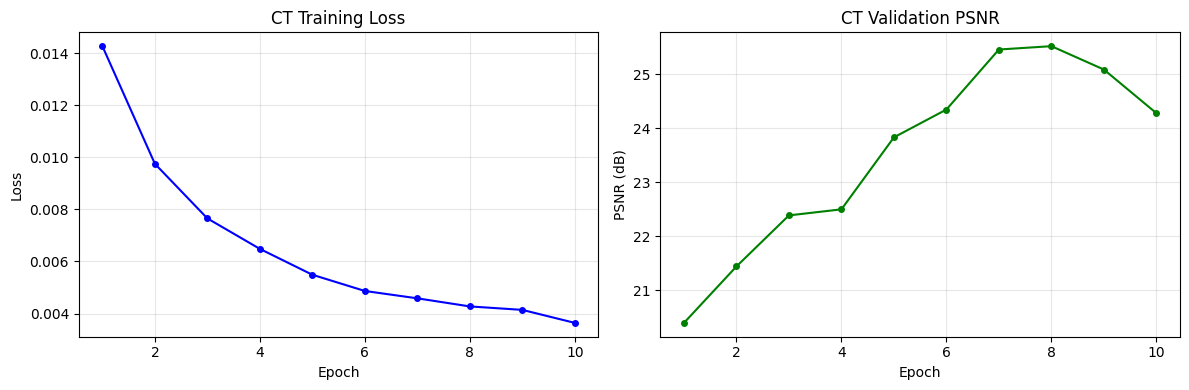

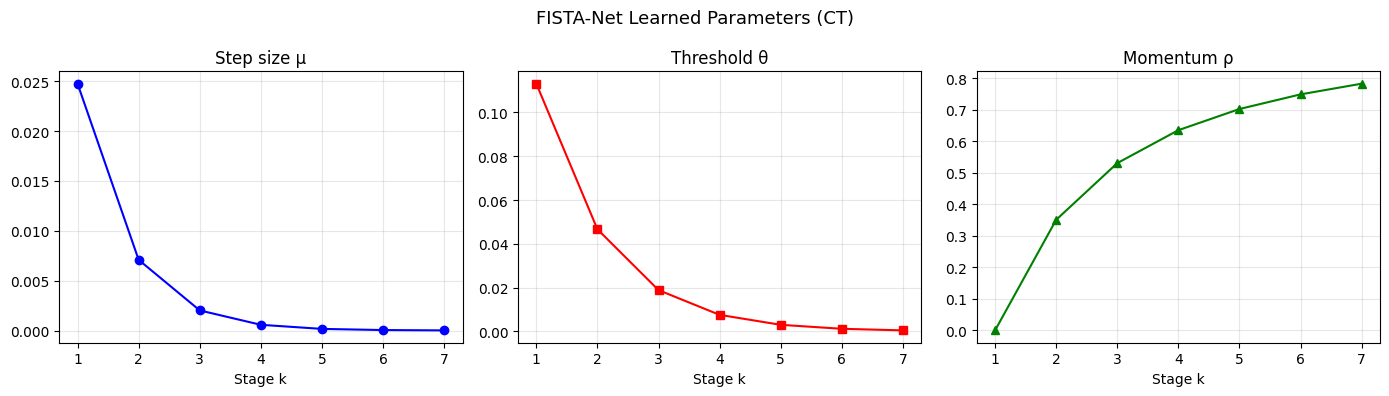

All plots saved.


In [ ]:
# ── Validation PSNR training curve ───────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(history_ct['train_loss']) + 1)
ax1.plot(epochs, history_ct['train_loss'], 'b-o', markersize=4)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('CT Training Loss'); ax1.grid(alpha=0.3)

ax2.plot(epochs, history_ct['val_psnr'], 'g-o', markersize=4)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('PSNR (dB)')
ax2.set_title('CT Validation PSNR'); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ct_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Learned parameter schedules ───────────────────────────────────────────────
mus, thetas, rhos = fista_net_ct.get_learned_params()
stages = list(range(1, len(mus) + 1))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(stages, mus,    'b-o'); axes[0].set_title('Step size μ')
axes[1].plot(stages, thetas, 'r-s'); axes[1].set_title('Threshold θ')
axes[2].plot(stages, rhos,   'g-^'); axes[2].set_title('Momentum ρ')
for ax in axes:
    ax.set_xlabel('Stage k'); ax.grid(alpha=0.3)
plt.suptitle('FISTA-Net Learned Parameters (CT)', fontsize=13)
plt.tight_layout()
plt.savefig('ct_learned_params.png', dpi=150, bbox_inches='tight')
plt.show()
print('All plots saved.')

---
# 📊  CT Full Evaluation & Model Comparison (Paper Table Replication)

Compares **all methods** on the Mayo Clinic sparse-view (60-view) CT test set.
Metrics: **PSNR (dB) ↑ · SSIM ↑ · RMSE ↓**

| Method        | Notes |
|---------------|-------|
| FBP           | Filtered back-projection — no learning |
| FISTA-TV      | Classical iterative TV minimisation |
| ISTA-Net      | Unrolled ISTA (no momentum), same #stages |
| FBPConvNet    | U-Net post-processor applied to FBP |
| **FISTA-Net** | **Proposed — unrolled FISTA with learned params** |
---


## A. Train ISTA-Net for CT

In [ ]:
# ── ISTA-Net CT training (uses RadonOperator, no momentum) ──────────────────
def train_ista_net_ct(ista_model, radon_op, train_loader, val_loader,
                      n_epochs=10, lr_net=1e-4, lr_params=1e-3,
                      lambda1=0.01, lambda2=0.001, device=DEVICE):
    ista_model = ista_model.to(device)
    optimizer  = torch.optim.Adam([
        {'params': list(ista_model.prox_net.parameters()), 'lr': lr_net},
        {'params': list(ista_model.mus) + list(ista_model.thetas),  'lr': lr_params},
    ])
    best_psnr, best_state = -float('inf'), None
    history = {'train_loss': [], 'val_psnr': []}

    for epoch in range(1, n_epochs + 1):
        ista_model.train(); ep_loss = 0.
        for fbp, sino, gt in tqdm(train_loader, desc=f'ISTA-Net CT Epoch {epoch}/{n_epochs}', leave=False):
            fbp, sino, gt = fbp.to(device), sino.to(device), gt.to(device)
            x = fbp; ints = []
            for k in range(ista_model.Ns):
                mu    = ista_model.mus[k]
                theta = ista_model.thetas[k]
                Ax    = radon_op.batch_forward(x).to(device)
                r     = x - mu * radon_op.batch_adjoint(Ax - sino).to(device)
                x, z  = ista_model.prox_net(r, theta)
                ints.append((x, z))
            loss, *_ = fista_net_loss(x, ints, gt, ista_model.prox_net, lambda1, lambda2)
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(ista_model.parameters(), 1.0)
            optimizer.step(); ep_loss += loss.item()

        ista_model.eval(); val_psnrs = []
        with torch.no_grad():
            for fbp, sino, gt in val_loader:
                fbp, sino, gt = fbp.to(device), sino.to(device), gt.to(device)
                x = fbp
                for k in range(ista_model.Ns):
                    mu = ista_model.mus[k]; theta = ista_model.thetas[k]
                    Ax = radon_op.batch_forward(x).to(device)
                    r  = x - mu * radon_op.batch_adjoint(Ax - sino).to(device)
                    x, _ = ista_model.prox_net(r, theta)
                for p, g in zip(x.squeeze(1).cpu().numpy(), gt.squeeze(1).cpu().numpy()):
                    val_psnrs.append(psnr(g, p, data_range=max(g.max()-g.min(), 1e-8)))

        avg_vp = np.mean(val_psnrs)
        history['train_loss'].append(ep_loss / len(train_loader))
        history['val_psnr'].append(avg_vp)
        if avg_vp > best_psnr:
            best_psnr = avg_vp; best_state = copy.deepcopy(ista_model.state_dict())
        if epoch % 5 == 0:
            print(f'  Epoch {epoch:3d} | Loss: {ep_loss/len(train_loader):.4f} | Val PSNR: {avg_vp:.2f} dB')

    ista_model.load_state_dict(best_state)
    print(f'ISTA-Net CT done. Best Val PSNR: {best_psnr:.2f} dB')
    return ista_model, history


from copy import deepcopy as copy_deepcopy
import copy

# Build and train ISTA-Net for CT
ista_net_ct = ISTANet(torch.eye(1), n_stages=7, n_filters=32,
                      image_size=eff_size).to(DEVICE)
print(f'ISTA-Net CT params: {sum(p.numel() for p in ista_net_ct.parameters()):,}')

ista_net_ct, history_ista_ct = train_ista_net_ct(
    ista_net_ct, radon_op, train_loader_ct, val_loader_ct,
    n_epochs=N_EPOCHS_CT, device=DEVICE)
torch.save(ista_net_ct.state_dict(), 'ista_net_ct_mayo.pth')
print('Saved → ista_net_ct_mayo.pth')


## B. Train FBPConvNet for CT

In [ ]:
# ── FBPConvNet CT training (U-Net post-processes FBP directly) ───────────────
def train_fbpconvnet_ct(fbpconv_model, train_loader, val_loader,
                        n_epochs=10, lr=1e-4, device=DEVICE):
    fbpconv_model = fbpconv_model.to(device)
    optimizer = torch.optim.Adam(fbpconv_model.parameters(), lr=lr)
    best_psnr, best_state = -float('inf'), None
    history = {'train_loss': [], 'val_psnr': []}

    for epoch in range(1, n_epochs + 1):
        fbpconv_model.train(); ep_loss = 0.
        for fbp, sino, gt in tqdm(train_loader, desc=f'FBPConvNet CT Epoch {epoch}/{n_epochs}', leave=False):
            fbp, gt = fbp.to(device), gt.to(device)
            pred = fbpconv_model(fbp)
            loss = F.mse_loss(pred, gt)
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(fbpconv_model.parameters(), 1.0)
            optimizer.step(); ep_loss += loss.item()

        fbpconv_model.eval(); val_psnrs = []
        with torch.no_grad():
            for fbp, sino, gt in val_loader:
                fbp, gt = fbp.to(device), gt.to(device)
                pred = fbpconv_model(fbp)
                for p, g in zip(pred.squeeze(1).cpu().numpy(), gt.squeeze(1).cpu().numpy()):
                    val_psnrs.append(psnr(g, p, data_range=max(g.max()-g.min(), 1e-8)))

        avg_vp = np.mean(val_psnrs)
        history['train_loss'].append(ep_loss / len(train_loader))
        history['val_psnr'].append(avg_vp)
        if avg_vp > best_psnr:
            best_psnr = avg_vp; best_state = copy.deepcopy(fbpconv_model.state_dict())
        if epoch % 5 == 0:
            print(f'  Epoch {epoch:3d} | Loss: {ep_loss/len(train_loader):.4f} | Val PSNR: {avg_vp:.2f} dB')

    fbpconv_model.load_state_dict(best_state)
    print(f'FBPConvNet CT done. Best Val PSNR: {best_psnr:.2f} dB')
    return fbpconv_model, history


fbpconvnet_ct = FBPConvNet(base_ch=32).to(DEVICE)
print(f'FBPConvNet CT params: {sum(p.numel() for p in fbpconvnet_ct.parameters()):,}')

fbpconvnet_ct, history_fbpconv_ct = train_fbpconvnet_ct(
    fbpconvnet_ct, train_loader_ct, val_loader_ct,
    n_epochs=N_EPOCHS_CT, device=DEVICE)
torch.save(fbpconvnet_ct.state_dict(), 'fbpconvnet_ct_mayo.pth')
print('Saved → fbpconvnet_ct_mayo.pth')


## C. FISTA-TV Baseline for CT (Classical)

In [ ]:
# ── FISTA-TV for CT using Radon/iRadon ───────────────────────────────────────
# Operates on single 2-D numpy images using the same Radon angles as training.

def fista_tv_ct(fbp_img, sino_np, angles, n_iters=100, lam=0.005, step=0.001):
    """
    TV-regularised FISTA for CT reconstruction.
    fbp_img  : H x W numpy array (FBP initialisation, [0,1] range)
    sino_np  : H x n_views numpy sinogram
    angles   : view angles (degrees)
    """
    from skimage.transform import radon as sk_radon, iradon as sk_iradon

    def forward(x):   return sk_radon(x, theta=angles, circle=True)
    def adjoint(s):   return sk_iradon(s, theta=angles, filter_name='ramp', circle=True)

    # Lipschitz constant estimate: step = 1 / ||A^T A||
    mu = step
    x  = fbp_img.copy(); y = x.copy(); t = 1.0; x_prev = x.copy()

    for _ in range(n_iters):
        # Gradient of data fidelity: A^T (A x - b)
        grad = adjoint(forward(y) - sino_np)
        r    = y - mu * grad

        # TV proximal step (isotropic, forward-difference)
        dx   = np.diff(r, axis=1, append=r[:, -1:])
        dy   = np.diff(r, axis=0, append=r[-1:, :])
        mag  = np.sqrt(dx**2 + dy**2 + 1e-8)
        dx  /= mag; dy /= mag
        div  = (dx - np.roll(dx, 1, axis=1) + dy - np.roll(dy, 1, axis=0))
        x    = np.clip(r - lam * mu * div, 0, 1)

        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        y     = x + ((t - 1) / t_new) * (x - x_prev)
        x_prev, t = x.copy(), t_new

    return x.astype(np.float32)


print('fista_tv_ct defined (classical FISTA-TV for CT).')


## D. Comprehensive CT Evaluation — All Methods

In [ ]:
# ── Full CT comparison: FBP | FISTA-TV | ISTA-Net | FBPConvNet | FISTA-Net ──
ANGLES_CT = np.linspace(0., 180., N_VIEWS, endpoint=False)

def run_fista_net_ct_inference(model, fbp, sino, radon_op, device):
    model.eval()
    with torch.no_grad():
        fbp_t  = fbp.to(device)
        sino_t = sino.to(device)
        x_prev = y = fbp_t
        for k in range(1, model.Ns + 1):
            mu    = model._mu(k)
            theta = model._theta(k)
            rho   = model._rho(k)
            Ay    = radon_op.batch_forward(y).to(device)
            r     = y - mu * radon_op.batch_adjoint(Ay - sino_t).to(device)
            x, _  = model.prox_net(r, theta)
            y     = x + rho * (x - x_prev); x_prev = x
    return x.squeeze(1).cpu().numpy()


def run_ista_net_ct_inference(model, fbp, sino, radon_op, device):
    model.eval()
    with torch.no_grad():
        fbp_t  = fbp.to(device)
        sino_t = sino.to(device)
        x      = fbp_t
        for k in range(model.Ns):
            mu    = model.mus[k]
            theta = model.thetas[k]
            Ax    = radon_op.batch_forward(x).to(device)
            r     = x - mu * radon_op.batch_adjoint(Ax - sino_t).to(device)
            x, _  = model.prox_net(r, theta)
    return x.squeeze(1).cpu().numpy()


def evaluate_all_ct(fista_model, ista_model, fbpconv_model, radon_op,
                    test_loader, angles=ANGLES_CT,
                    fista_tv_iters=50, device=DEVICE):
    """
    Returns dict:  method -> {'PSNR': list, 'SSIM': list, 'RMSE': list}
    Methods: FBP, FISTA-TV, ISTA-Net, FBPConvNet, FISTA-Net
    """
    methods = ['FBP', 'FISTA-TV', 'ISTA-Net', 'FBPConvNet', 'FISTA-Net']
    res = {m: {'PSNR': [], 'SSIM': [], 'RMSE': []} for m in methods}

    for batch_idx, (fbp, sino, gt) in enumerate(
            tqdm(test_loader, desc='Evaluating all CT methods')):

        fbp_np  = fbp.squeeze(1).numpy()   # B x H x W
        sino_np = sino.squeeze(1).numpy()  # B x H x n_views (note: stored as H x n_views)
        gt_np   = gt.squeeze(1).numpy()    # B x H x W

        # ── FBP (direct) ──────────────────────────────────────────
        for p, g in zip(fbp_np, gt_np):
            dr = max(g.max() - g.min(), 1e-8)
            res['FBP']['PSNR'].append(psnr(g, p, data_range=dr))
            res['FBP']['SSIM'].append(ssim(g, p, data_range=dr))
            res['FBP']['RMSE'].append(float(np.sqrt(np.mean((p - g) ** 2))))

        # ── FISTA-TV (classical) ──────────────────────────────────
        for p_fbp, s_np, g in zip(fbp_np, sino_np, gt_np):
            # sino_np stored as (H, n_views) — reorder to (n_views_dim, H) if needed
            # skimage radon returns (n_pixels_along_ray, n_angles)
            p_tv = fista_tv_ct(p_fbp, s_np, angles, n_iters=fista_tv_iters)
            dr = max(g.max() - g.min(), 1e-8)
            res['FISTA-TV']['PSNR'].append(psnr(g, p_tv, data_range=dr))
            res['FISTA-TV']['SSIM'].append(ssim(g, p_tv, data_range=dr))
            res['FISTA-TV']['RMSE'].append(float(np.sqrt(np.mean((p_tv - g) ** 2))))

        # ── ISTA-Net ──────────────────────────────────────────────
        ista_pred = run_ista_net_ct_inference(ista_model, fbp, sino, radon_op, device)
        for p, g in zip(ista_pred, gt_np):
            dr = max(g.max() - g.min(), 1e-8)
            res['ISTA-Net']['PSNR'].append(psnr(g, p, data_range=dr))
            res['ISTA-Net']['SSIM'].append(ssim(g, p, data_range=dr))
            res['ISTA-Net']['RMSE'].append(float(np.sqrt(np.mean((p - g) ** 2))))

        # ── FBPConvNet ────────────────────────────────────────────
        fbpconv_model.eval()
        with torch.no_grad():
            fbpc_pred = fbpconv_model(fbp.to(device)).squeeze(1).cpu().numpy()
        for p, g in zip(fbpc_pred, gt_np):
            dr = max(g.max() - g.min(), 1e-8)
            res['FBPConvNet']['PSNR'].append(psnr(g, p, data_range=dr))
            res['FBPConvNet']['SSIM'].append(ssim(g, p, data_range=dr))
            res['FBPConvNet']['RMSE'].append(float(np.sqrt(np.mean((p - g) ** 2))))

        # ── FISTA-Net ─────────────────────────────────────────────
        fista_pred = run_fista_net_ct_inference(fista_model, fbp, sino, radon_op, device)
        for p, g in zip(fista_pred, gt_np):
            dr = max(g.max() - g.min(), 1e-8)
            res['FISTA-Net']['PSNR'].append(psnr(g, p, data_range=dr))
            res['FISTA-Net']['SSIM'].append(ssim(g, p, data_range=dr))
            res['FISTA-Net']['RMSE'].append(float(np.sqrt(np.mean((p - g) ** 2))))

    return res


ct_all_results = evaluate_all_ct(
    fista_net_ct, ista_net_ct, fbpconvnet_ct, radon_op, test_loader_ct, device=DEVICE)
print('Evaluation complete.')


## E. Paper-Style Comparison Table (CT)

In [ ]:
\
# ── Print Table III equivalent (Mayo Clinic CT, 60-view sparse) ──────────────
def print_ct_table(results, title='CT Reconstruction Comparison (Mayo Clinic, 60-view)'):
    import statistics
    sep = '═' * 68
    print(f'\n{sep}')
    print(f'  {title}')
    print(sep)
    print(f'  {"Method":<16} {"PSNR (dB)":>14} {"SSIM":>14} {"RMSE":>14}')
    print('─' * 68)
    for method, mets in results.items():
        psnr_m  = np.mean(mets['PSNR']);  psnr_s  = np.std(mets['PSNR'])
        ssim_m  = np.mean(mets['SSIM']);  ssim_s  = np.std(mets['SSIM'])
        rmse_m  = np.mean(mets['RMSE']);  rmse_s  = np.std(mets['RMSE'])
        star = ' ◄' if method == 'FISTA-Net' else '  '
        print(f'  {method:<16} '
              f'{psnr_m:>7.3f}±{psnr_s:<5.3f}  '
              f'{ssim_m:>6.4f}±{ssim_s:<5.4f}  '
              f'{rmse_m:>6.4f}±{rmse_s:<5.4f}{star}')
    print(sep)
    print('  ◄ Proposed method (FISTA-Net)  |  ↑ higher is better  |  ↓ lower is better')
    print(sep)


print_ct_table(ct_all_results)

# Also save to dict for later use
ct_means = {m: {k: float(np.mean(v)) for k, v in mets.items()}
            for m, mets in ct_all_results.items()}
print('\nMeans stored in ct_means.')


## F. Visual Reconstruction Comparison (Paper Figure Style)

In [ ]:
# ── Side-by-side reconstruction: FBP | FISTA-TV | ISTA-Net | FBPConvNet | FISTA-Net | GT ──
N_DISP     = 3   # number of test slices to display
ANGLES_CT  = np.linspace(0., 180., N_VIEWS, endpoint=False)

display_rows = []  # list of dicts per sample

with torch.no_grad():
    for fbp, sino, gt in test_loader_ct:
        if len(display_rows) >= N_DISP:
            break

        fbp_np  = fbp.squeeze(1).numpy()
        sino_np = sino.squeeze(1).numpy()
        gt_np   = gt.squeeze(1).numpy()

        # All deep models in eval mode
        fista_pred  = run_fista_net_ct_inference(fista_net_ct,  fbp, sino, radon_op, DEVICE)
        ista_pred   = run_ista_net_ct_inference(ista_net_ct,    fbp, sino, radon_op, DEVICE)
        fbpconv_model = fbpconvnet_ct
        fbpconv_model.eval()
        fbpc_pred   = fbpconv_model(fbp.to(DEVICE)).squeeze(1).cpu().numpy()

        for i in range(fbp.shape[0]):
            if len(display_rows) >= N_DISP:
                break
            fbp_i    = fbp_np[i]
            sino_i   = sino_np[i]
            gt_i     = gt_np[i]
            tv_i     = fista_tv_ct(fbp_i, sino_i, ANGLES_CT, n_iters=50)
            dr       = max(gt_i.max() - gt_i.min(), 1e-8)

            row = {'FBP': fbp_i, 'FISTA-TV': tv_i, 'ISTA-Net': ista_pred[i],
                   'FBPConvNet': fbpc_pred[i], 'FISTA-Net': fista_pred[i], 'GT': gt_i,
                   'dr': dr}
            # Per-method metrics
            row['metrics'] = {}
            for name in ['FBP', 'FISTA-TV', 'ISTA-Net', 'FBPConvNet', 'FISTA-Net']:
                p = row[name]
                row['metrics'][name] = {
                    'PSNR': psnr(gt_i, p, data_range=dr),
                    'SSIM': ssim(gt_i, p, data_range=dr),
                    'RMSE': float(np.sqrt(np.mean((p - gt_i)**2)))}
            display_rows.append(row)


COLS  = ['FBP', 'FISTA-TV', 'ISTA-Net', 'FBPConvNet', 'FISTA-Net', 'GT']
NCOLS = len(COLS)
NROWS = N_DISP

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(4 * NCOLS, 4 * NROWS))
if NROWS == 1:
    axes = axes[np.newaxis, :]

for col, cname in enumerate(COLS):
    axes[0, col].set_title(cname, fontsize=12, fontweight='bold',
                           color='red' if cname == 'FISTA-Net' else 'black')

for row_idx, row in enumerate(display_rows):
    vmin, vmax = row['GT'].min(), row['GT'].max()
    for col, cname in enumerate(COLS):
        ax  = axes[row_idx, col]
        img = row[cname]
        ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
        ax.axis('off')
        if cname != 'GT':
            m = row['metrics'][cname]
            ax.set_xlabel(f"PSNR:{m['PSNR']:.2f} SSIM:{m['SSIM']:.3f}",
                          fontsize=7)

plt.suptitle(f'CT Reconstruction Comparison — Mayo Clinic ({N_VIEWS}-view sparse)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('ct_comparison_all_methods.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ct_comparison_all_methods.png')


## G. Quantitative Bar Charts & Metric Distribution

In [ ]:
# ── Bar charts for PSNR / SSIM / RMSE ────────────────────────────────────────
methods = list(ct_all_results.keys())
colors  = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759', '#76b7b2']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_info = [('PSNR', 'PSNR (dB)', True), ('SSIM', 'SSIM', True), ('RMSE', 'RMSE', False)]

for ax, (metric, ylabel, higher_better) in zip(axes, metrics_info):
    means = [np.mean(ct_all_results[m][metric]) for m in methods]
    stds  = [np.std(ct_all_results[m][metric])  for m in methods]
    bars  = ax.bar(methods, means, yerr=stds, capsize=5,
                   color=colors, edgecolor='k', linewidth=0.8, alpha=0.88)
    # Highlight FISTA-Net bar
    bars[-1].set_edgecolor('darkred'); bars[-1].set_linewidth(2)
    ax.set_title(ylabel, fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(methods, rotation=30, ha='right', fontsize=10)
    arrow = '↑ higher better' if higher_better else '↓ lower better'
    ax.text(0.98, 0.98, arrow, transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='gray')
    ax.grid(axis='y', alpha=0.3)
    # Annotate bars
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(stds)*0.05,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('CT Reconstruction Metrics — Mayo Clinic 60-view Sparse CT', fontsize=14)
plt.tight_layout()
plt.savefig('ct_metrics_barchart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ct_metrics_barchart.png')


# ── Box plots for distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (metric, ylabel, _) in zip(axes, metrics_info):
    data = [ct_all_results[m][metric] for m in methods]
    bp   = ax.boxplot(data, labels=methods, patch_artist=True, notch=False,
                      medianprops=dict(color='black', linewidth=2))
    for patch, col in zip(bp['boxes'], colors):
        patch.set_facecolor(col); patch.set_alpha(0.7)
    ax.set_title(f'{ylabel} Distribution', fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(methods, rotation=30, ha='right', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('CT Metric Distributions Across Test Slices', fontsize=14)
plt.tight_layout()
plt.savefig('ct_metrics_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ct_metrics_boxplot.png')


## H. Learned Parameter Schedules (CT) — Paper Figure

In [ ]:
# ── Plot learned μ, θ, ρ across stages for FISTA-Net (CT) ────────────────────
mus, thetas, rhos = fista_net_ct.get_learned_params()
stages = list(range(1, len(mus) + 1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
param_info = [('Step size μ', mus, 'b-o'), ('Threshold θ', thetas, 'r-s'), ('Momentum ρ', rhos, 'g-^')]

for ax, (label, vals, style) in zip(axes, param_info):
    ax.plot(stages, vals, style, markersize=7, linewidth=2, label='CT')
    ax.set_xlabel('Stage k', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(f'Learned {label}', fontsize=13)
    ax.set_xticks(stages)
    ax.grid(alpha=0.4)

plt.suptitle('FISTA-Net Learned Parameter Schedules (CT, Mayo Clinic)', fontsize=14)
plt.tight_layout()
plt.savefig('ct_learned_params_schedule.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ct_learned_params_schedule.png')

# Print learned values
print(f'\nLearned parameters across {len(stages)} stages:')
print(f'  μ   : {[f"{v:.4f}" for v in mus]}')
print(f'  θ   : {[f"{v:.4f}" for v in thetas]}')
print(f'  ρ   : {[f"{v:.4f}" for v in rhos]}')


## I. Training Curves — All CT Models

In [ ]:
# ── Validation PSNR training curves for all deep models ──────────────────────
histories = {
    'FISTA-Net':   history_ct['val_psnr'],
    'ISTA-Net':    history_ista_ct['val_psnr'],
    'FBPConvNet':  history_fbpconv_ct['val_psnr'],
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Val PSNR per model
colors_map = {'FISTA-Net': 'red', 'ISTA-Net': 'blue', 'FBPConvNet': 'green'}
for name, vals in histories.items():
    epochs = range(1, len(vals) + 1)
    ax1.plot(epochs, vals, '-o', markersize=5, linewidth=2,
             color=colors_map[name], label=name)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Val PSNR (dB)')
ax1.set_title('Validation PSNR — CT Models')
ax1.legend(); ax1.grid(alpha=0.3)

# Train loss
train_losses = {
    'FISTA-Net':   history_ct['train_loss'],
    'ISTA-Net':    history_ista_ct['train_loss'],
    'FBPConvNet':  history_fbpconv_ct['train_loss'],
}
for name, vals in train_losses.items():
    epochs = range(1, len(vals) + 1)
    ax2.plot(epochs, vals, '-o', markersize=5, linewidth=2,
             color=colors_map[name], label=name)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Train Loss')
ax2.set_title('Training Loss — CT Models')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('CT Model Training Curves (Mayo Clinic)', fontsize=14)
plt.tight_layout()
plt.savefig('ct_training_curves_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ct_training_curves_all.png')


## J. Error Map Comparison (Absolute Residual)

In [ ]:
# ── Error maps |pred - GT| for each method on the first test sample ───────────
sample = display_rows[0]
gt_img = sample['GT']
methods_to_plot = ['FBP', 'FISTA-TV', 'ISTA-Net', 'FBPConvNet', 'FISTA-Net']

fig, axes = plt.subplots(2, len(methods_to_plot), figsize=(4 * len(methods_to_plot), 8))

vmin, vmax = gt_img.min(), gt_img.max()
err_vmax   = max(np.abs(sample[m] - gt_img).max() for m in methods_to_plot)

for col, mname in enumerate(methods_to_plot):
    pred    = sample[mname]
    err_map = np.abs(pred - gt_img)
    met     = sample['metrics'][mname]

    ax_img = axes[0, col]
    ax_err = axes[1, col]

    ax_img.imshow(pred, cmap='gray', vmin=vmin, vmax=vmax)
    ax_img.set_title(mname, fontsize=11,
                     fontweight='bold' if mname == 'FISTA-Net' else 'normal',
                     color='red' if mname == 'FISTA-Net' else 'black')
    ax_img.set_xlabel(f"PSNR:{met['PSNR']:.2f}dB SSIM:{met['SSIM']:.4f}", fontsize=8)
    ax_img.axis('off')

    im = ax_err.imshow(err_map, cmap='hot', vmin=0, vmax=err_vmax)
    ax_err.set_title(f'|Error| max={err_map.max():.4f}', fontsize=9)
    ax_err.axis('off')
    plt.colorbar(im, ax=ax_err, fraction=0.046, pad=0.04)

axes[0, 0].set_ylabel('Reconstruction', fontsize=10)
axes[1, 0].set_ylabel('|Error Map|',    fontsize=10)

plt.suptitle('Reconstruction vs Error Maps — CT (Mayo Clinic, 60-view)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('ct_error_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ct_error_maps.png')


## K. Final Summary — CT Results

In [ ]:
\
# ── Final summary matching paper Table style ──────────────────────────────────
print_ct_table(ct_all_results,
               title=f'Table: CT Sparse-View Reconstruction ({N_VIEWS} views, Mayo Clinic)')

# Best method per metric
best_psnr_m = max(ct_means, key=lambda m: ct_means[m]['PSNR'])
best_ssim_m = max(ct_means, key=lambda m: ct_means[m]['SSIM'])
best_rmse_m = min(ct_means, key=lambda m: ct_means[m]['RMSE'])

print(f'\n  Best PSNR : {best_psnr_m} ({ct_means[best_psnr_m]["PSNR"]:.3f} dB)')
print(f'  Best SSIM : {best_ssim_m} ({ct_means[best_ssim_m]["SSIM"]:.4f})')
print(f'  Best RMSE : {best_rmse_m} ({ct_means[best_rmse_m]["RMSE"]:.4f})')

# Improvement of FISTA-Net over FBP
delta_psnr = ct_means['FISTA-Net']['PSNR'] - ct_means['FBP']['PSNR']
delta_ssim = ct_means['FISTA-Net']['SSIM'] - ct_means['FBP']['SSIM']
print(f'\n  FISTA-Net gain over FBP: ΔPSNR = {delta_psnr:+.3f} dB | ΔSSIM = {delta_ssim:+.4f}')
